The script computes a ratioed MTRDR CRISM cube. A ratioed cube is a spectral cube where each pixel has been divided by a spectrum showing no prominent absorption features or by the mean/median of several of such spectra from the same CRISM scene. Optimal spectra for this procedure are usually retrieved from a dusty surface since Mars’ dust spectrum is essentially flat in the near infrared. 

This notebook implements two different approaches to retrieve a ratioed cube: a mineral mask semi-automatic approach and a fully manual approach.

The mineral mask:
1) <b>identifies the most spectrally neutral pixels within a CRISM scene;</b>
2) <b>computes the average spectrum of selected neutral pixels;</b>
3) <b>divides the entire CRISM MTRDR reflectance cube by the computed neutal spectrum and saves it as a separate cube in ENVI format</b>

This approach was first ideated by <font color='orange'>Horgan et al. 2020</font> and applied to CRISM data in Jezero crater with good results. 

Spectrally neutral pixels are selected by manually setting threshold values on selected spectral parameters from <font color='orange'>Viviano-Beck et al 2014</font>. The chosen parameters can be personalized based on the user's needs. This version includes additional parameters to those already listed in <font color='orange'>Horgan et al. 2020</font>'s mineral mask in order to take into account possible sulfate detections within the scene. 

The fully manual approach:
1) <b>Lets the user choose a 25x25 pixel region within the CRISM scene. The assessment of whether the selected area is spectrally neutral can be done through visualization of the standard RGB browse products defined in <font color='orange'>Viviano-Beck et al 2014;</font></b>
2) <b>computes the average spectrum of selected pixels;</b>
3) <b>divides the entire CRISM MTRDR reflectance cube by the computed neutral spectrum and saves it as a separate cube in ENVI format</b>


<b>References:</b>

<i>Horgan, B. H. N., et al. (2020), The mineral diversity of Jezero crater: Evidence for possible lacustrine carbonates on Mars, Icarus, 339, doi:10.1016/j.icarus.2019.113526.</i>

<i>Viviano-Beck, C. E., et al. (2014), Revised CRISM spectral parameters and summary products based on the currently detected mineral diversity on Mars, J. Geophys. Res. Planets, 119, 1403–1431, doi:10.1002/2014JE004627.</i>

# Import

In [1]:
#ENVI image handling
from spectral import open_image
from spectral.io.envi import save_image

#path management
import pathlib

#plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

#pandas and numpy
import pandas as pd
import numpy as np

#image processing
from skimage import exposure

#warning management
import warnings

# Open image

In [2]:
#opening I/F file
img = open_image('data/frt0000bef5_07_if165j_mtr3.hdr')
wavelength = np.array(img.metadata['wavelength']).astype(float)
#converting img to simple array and putting no-values to NaN
nan_img = np.copy(img[:,:,:])
nan_img[nan_img>10]=np.nan

#opening refined spectral parameter file
img_sr = open_image('data/frt0000bef5_07_sr165j_mtr3.hdr')
sr_names = img_sr.metadata['band names']
#converting img_sr to simple array and putting no-values to NaN
nan_img_sr = np.copy(img_sr[:,:,:])
nan_img_sr[nan_img_sr>10]=np.nan

# Quick cube visualization

In [3]:
#some img statistics:
#----mean spectrum
mean_spec = np.nanmean(nan_img.reshape(-1,nan_img.shape[-1]), axis = 0)
#----standard dev
mean_spec_std = np.nanstd(nan_img.reshape(-1,nan_img.shape[-1]), axis = 0)

#create enhanced RGB true color image (@visible wavelengths):
wav_channels = [26,15,1] #600nm,530nm,440nm
wav_channels_text = ','.join([f'{c}:{w:.0f}nm' for c,w in zip(['R','G','B'],wavelength[wav_channels])]) #channels text for plot
RGB = img[:,:,wav_channels]

#contrast stretching: 
for ind, ch in enumerate (RGB.T):
    ch_mask = ch != 65535. #masking no-data values
    p2, p98 = np.nanpercentile(ch[ch_mask], (2, 98)) #2nd and 98th percentile ignoring no-data values (if present)
    RGB[:,:,ind] = exposure.rescale_intensity(ch, in_range=(p2, p98)).T #stretching

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


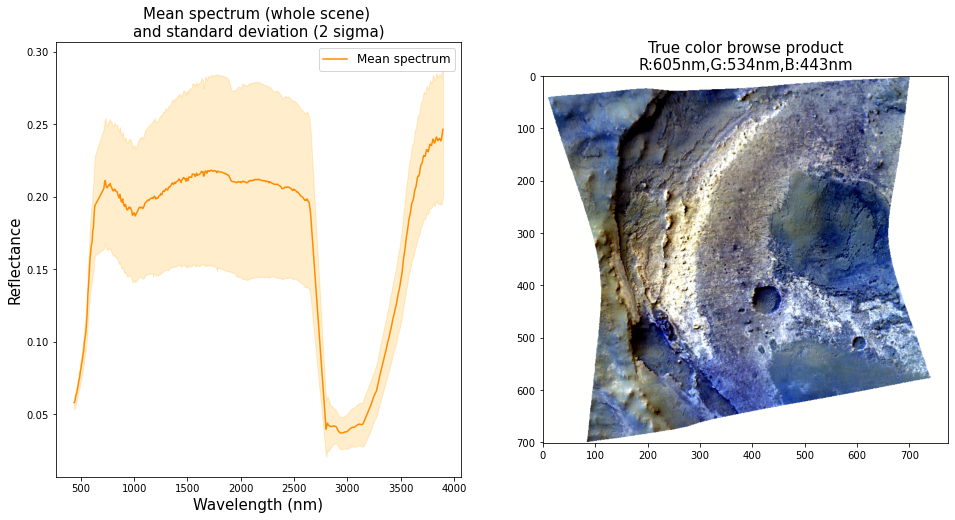

In [4]:
#plot
fig, axs = plt.subplots(ncols=2,figsize=[16,8])

#mean spectrum plot
axs[0].plot(wavelength, mean_spec, c='darkorange', label ='Mean spectrum')
axs[0].fill_between(wavelength, 
                    mean_spec-2*mean_spec_std, 
                    mean_spec+2*mean_spec_std, 
                    alpha=0.2, 
                    color='orange')
#title, labels, legend
axs[0].set_title('Mean spectrum (whole scene) \nand standard deviation (2 sigma)', size=15)
axs[0].set_xlabel('Wavelength (nm)', size=15)
axs[0].set_ylabel('Reflectance', size=15)
axs[0].legend(prop={'size': 12})

#RGB img plot
axs[1].set_title('True color browse product\n'+wav_channels_text, size = 15)
axs[1].imshow(RGB)

# Cube ratioing 

## METHOD 1: Mineral mask

In [5]:
#define a spectral parameter pandas dataframe
df_sr = pd.DataFrame(nan_img_sr.reshape(-1,nan_img_sr.shape[-1]),
            columns=img_sr.metadata['band names']
            )

#mineral mask constraints, modified after Horgan et al. 2020
#second element of constraints is the threshold value used to build the mask
#thresholds below are indicative and change with data, although they are usually close to zero (except R770), try playing with them! 
constraints = (
    ('R770'    ,0.15), 
    ('BDI1000IR'    ,0.04),
    ('OLINDEX3',0.1),
    ('BD1300', 0.0),
    ('LCPINDEX2', 0.0),
    ('HCPINDEX2', 0.01),
    ('D2200'   ,0.002), 
    ('BD2290', 0.001), 
    ('D2300', 0.001), 
    ('BD2500_2', 0), 
    ('SINDEX2', 0.002), 
    ('BD1900_2', 0.015) 
    
)

band_names_mask = [i for i,j in constraints] 
constr_values = [j for i,j in constraints]

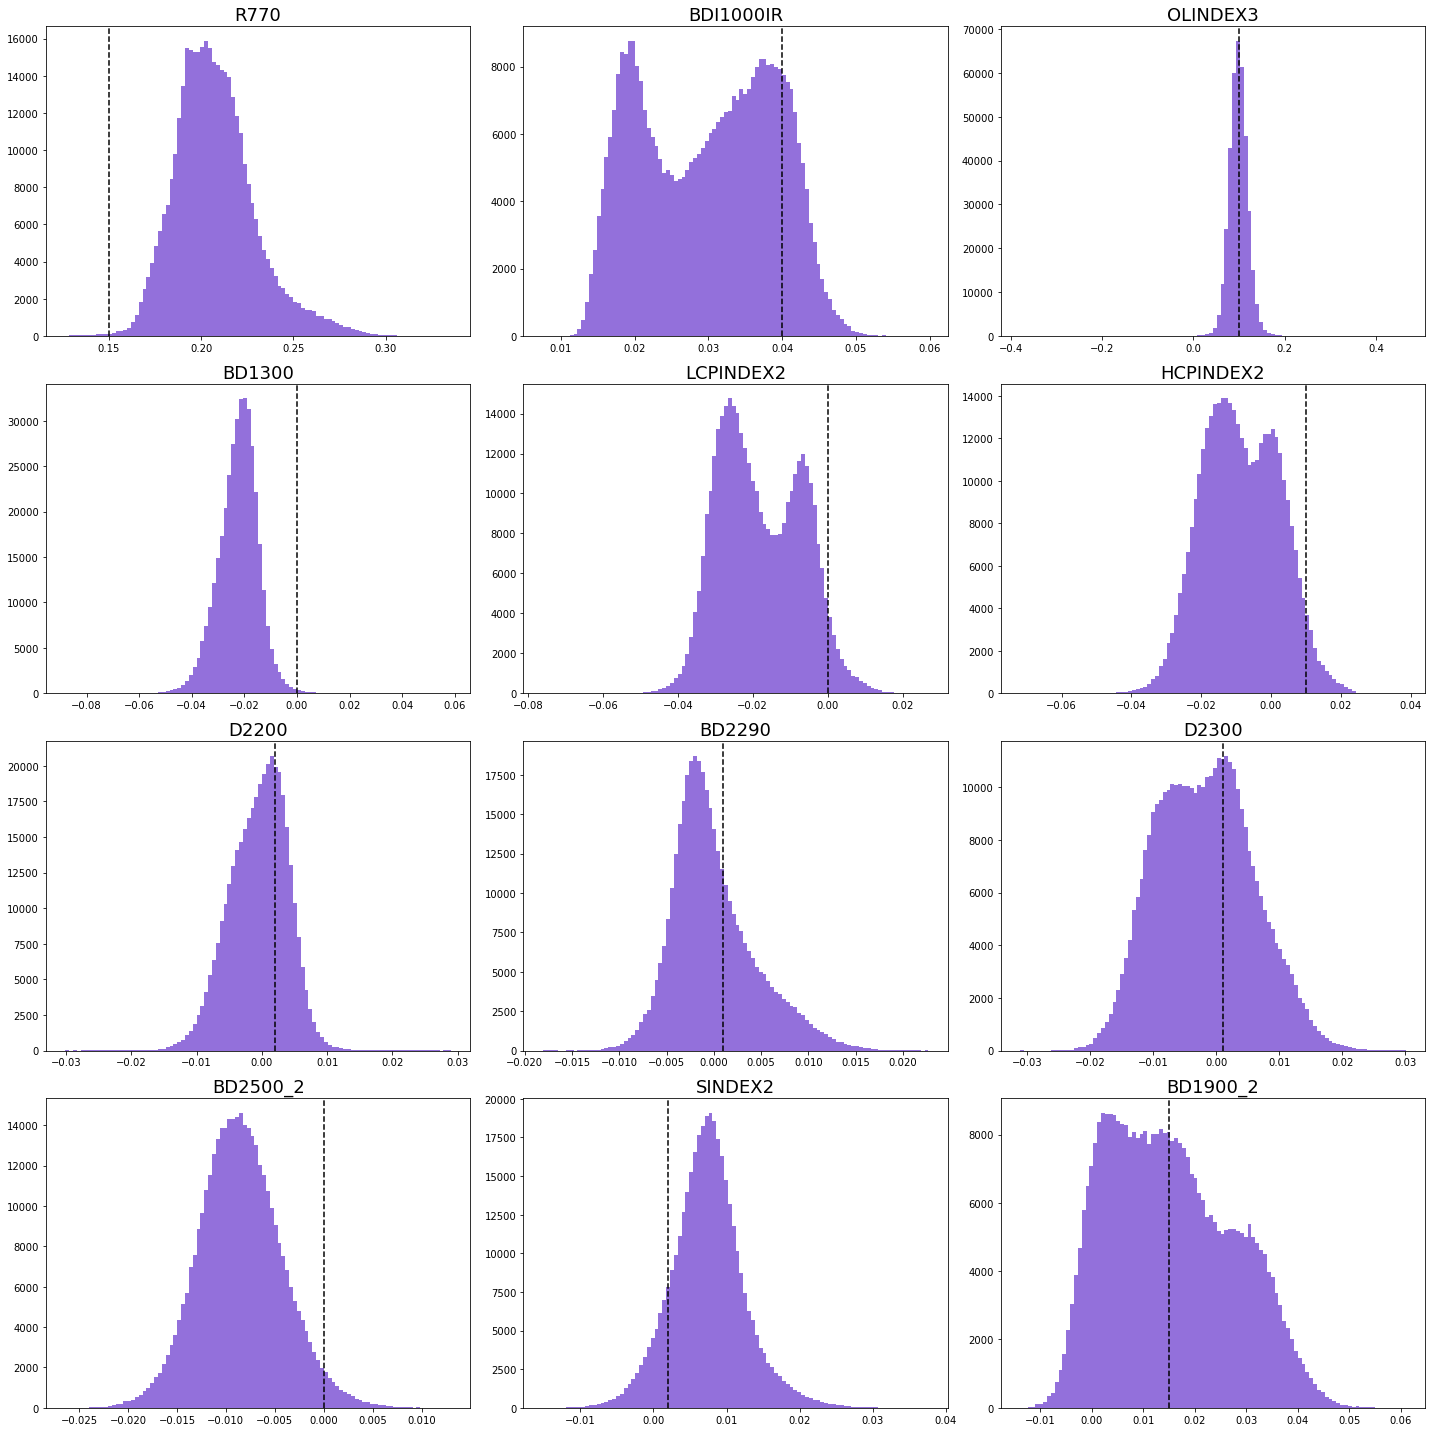

In [6]:
#histograms
histograms = df_sr[band_names_mask].hist(figsize=(20,20), bins=100, grid=False, color = 'mediumpurple')

#plotting
for i, h in enumerate(histograms.ravel()):
    h.title.set_size(18)
    h.axvline(constr_values[i], color='k', linestyle='--')
    
plt.tight_layout()

### Build and visualize mineral mask

In [7]:
#function to retrieve band index
def get_band_index(img,x):
    return img.metadata['band names'].index(x)

In [8]:
#building mineral mask 
constraints_ls = [] #each element of this list will contain an array with True/False values based on required condition

for b,v in constraints:
    if b == 'R770':
        #print(b,v)
        constraints_ls.append((img_sr[:,:,get_band_index(img_sr,b)] > v).squeeze()) #take all pixels with R770 > threshold
    else:
        #print(b,v)
        constraints_ls.append((img_sr[:,:,get_band_index(img_sr,b)] < v).squeeze()) #take all pixels with other params < threshold

constraints_mask = np.array(constraints_ls).sum(axis=0) == len(constraints_ls) #True = elements with all constraints true
print('Number of pixels selected by the mask = {}'.format(constraints_mask.sum()))

Number of pixels selected by the mask = 1528


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


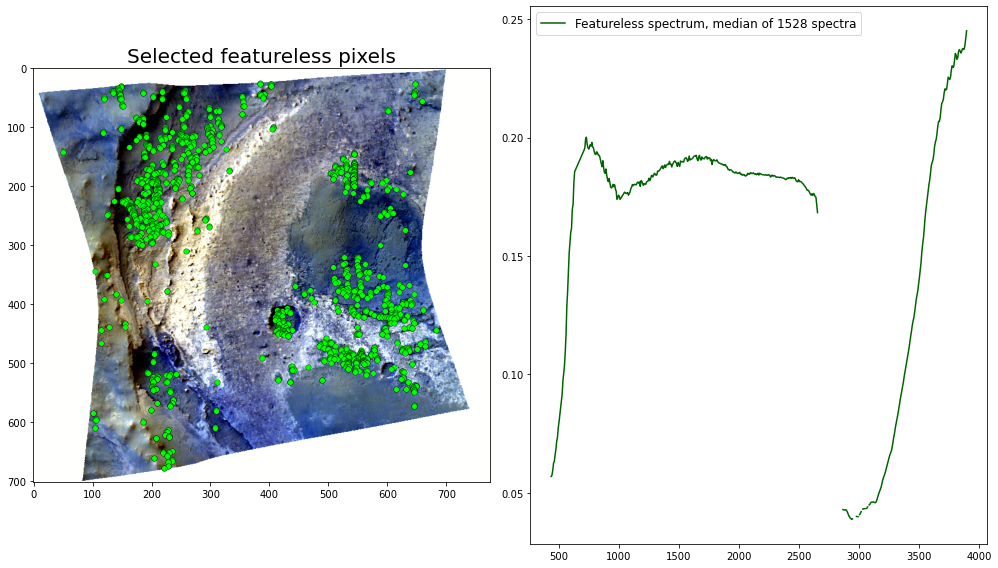

In [9]:
#plots
fig, axs = plt.subplots(ncols = 2, figsize=(14,8))

axs[0].set_title('Selected featureless pixels', size = 20) #title 
axs[0].imshow(RGB) #plot base image
cmap = colors.ListedColormap(['#00000000', '#00ff00']) 
mm_img = axs[0].imshow(constraints_mask, interpolation='None', cmap = cmap) #plot mask


#to visualize the neutral pixels as bigger dots, uncomment the block below
#'''
y, x = np.where(constraints_mask)
axs[0].scatter(
    x, y,
    s=30, #dot size
    c='lime',
    marker='o',
    edgecolors='black',
    linewidths=0.3
)
#'''


#computing mean or median of featureless spectra (uncomment relevant line)

#fless_mean_spec = np.mean(nan_img[constraints_mask==True,:], axis = 0) #mean
fless_median_spec = np.median(nan_img[constraints_mask==True,:], axis = 0) #median

#spectrum plot
axs[1].plot(wavelength,
            fless_median_spec,
            c='darkgreen', 
            label ='Featureless spectrum, median of {} spectra'.format(constraints_mask.sum()))

axs[1].legend(prop={'size': 12})

plt.tight_layout()

## METHOD 2: Manual approach

### List of standard RGB browse products

In [50]:
from browse_products import crism_browse_products
#print nicely
print("List of CRISM standard RGB browse products\n")
for name, desc, use in crism_browse_products:
    print(f"{name:12s} | {desc:60s} | {use}")

List of CRISM standard RGB browse products

TRU          | True color composite (R600, R530, R440)                      | Enhanced true color representation after photometric + atmospheric correction
VNA          | VNIR albedo (R770, R770, R770)                               | Photometrically corrected 770 nm reflectance; morphology + albedo contrast
TAN          | Tandem color composite (R2529, IRA, R770)                    | Visible-to-IR enhanced false color; broad mineral + morphology overview
IRA          | IR albedo (R1300, R1300, R1300)                              | Photometrically corrected 1.33 µm reflectance; IR brightness / morphology
FAL          | False color IR composite (R2529, R1506, R1080)               | Highlights mafic vs clay vs carbonate distributions
FEM          | Fe mineralogy (BD530_2, SH600_2, BDI1000VIS)                 | Sensitive to ferric/ferrous phases, dust coatings, and texture; red = ferric oxides
FM2          | Fe mineralogy v2 (BD530_2, BD920_2, BD

### Plot RGB standard browse products 

Most diagnostic RGB products for the visible-near infrared (VNIR) range are shown in a grid: MAF, HYD, PHY, PFM, PAL, HYS, ICE, CAR.

Default stretch is used (min value: 0, max value: 99th percentile).

Spectrally neutral regions should appear as black/dark pixels in all images.

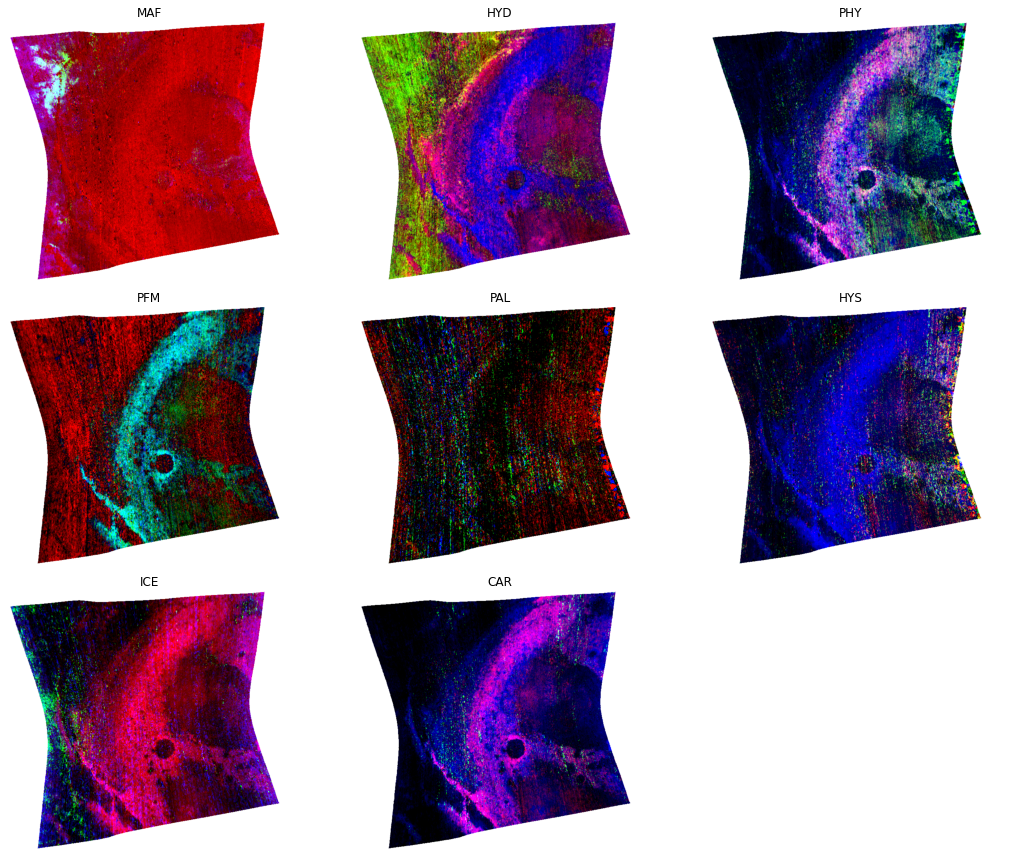

In [ ]:
products = [
    ("MAF", ["OLINDEX3","LCPINDEX2","HCPINDEX2"]),
    ("HYD", ["SINDEX2","BD2100_2","BD1900_2"]),
    ("PHY", ["D2300","D2200","BD1900R2"]),
    ("PFM", ["BD2355","D2300","BD2290"]),
    ("PAL", ["BD2210_2","BD2190","BD2165"]),
    ("HYS", ["MIN2250","BD2250","BD1900R2"]),
    ("ICE", ["BD1900_2","BD1500_2","BD1435"]),
    ("CAR", ["D2300","BD2500_2","BD1900_2"]),
]

#------------------ grid ------------------
ncols = 3
nrows = int(np.ceil(len(products) / ncols))

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4*nrows))
axs = axs.flatten()

#------------------ loop ------------------
for i, (pname, channels_names) in enumerate(products):

    sr_channels_number = [sr_names.index(cn) for cn in channels_names]

    RGB_browse = np.array(img_sr[:, :, sr_channels_number])

    min_all = np.array([0.0, 0, 0.0])
    max_all = np.nanpercentile(nan_img_sr[:, :, sr_channels_number], 99, axis=(0, 1))

    stretch = np.vstack((min_all, max_all)).T

    # contrast stretching
    for ind, ch in enumerate(RGB_browse.T):

        ch_mask = ch != 65535.
        p99 = np.nanpercentile(ch[ch_mask], 99)

        if p99 >= min_all[ind]:
            RGB_browse[:, :, ind] = exposure.rescale_intensity(
                ch,
                in_range=(min_all[ind], p99)
            ).T
        else:
            print(pname, products[i][1][ind]+":")
            print("Warning! All values are smaller than 0, they will now be set to 0")
            RGB_browse[:, :, ind] = 0

    #plot
    axs[i].imshow(RGB_browse)
    axs[i].set_title(pname)
    axs[i].axis("off")

#remove empty axes
for j in range(i+1, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()

In [67]:
#default matplotlib visualization is needed for the next block!
%matplotlib 

Using matplotlib backend: MacOSX


In [ ]:
%matplotlib 
reference_RGB = RGB #visualize interactively the true color browse, click on the image to select the neutral region!

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(reference_RGB)
ax.set_title("Choose a neutral area") 

#select central pixel of the 25x25 box
coords_d = np.asarray(
    fig.ginput(1, timeout=-1)
).astype(int).squeeze()

plt.close(fig) #if the figure does not close, you can still proceed to the next blocks, your choice has been recorded

#print coordinates of selected pixel
print("coordinates of the centre of the box -> X = {}; Y = {} ".format(coords_d[0], coords_d[1])) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


coordinates of the centre of the box -> X = 184; Y = 166 


In [ ]:
#or directly give the central coordinates of 25x25 pixel box ... uncomment the line below!
#coords_d = [107,244]

Computing the mean of 625 spectra...
done!


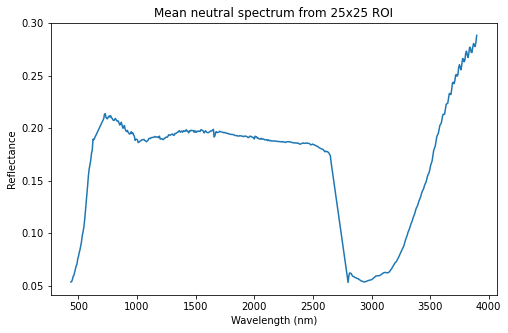

In [77]:
x_d, y_d = int(coords_d[0]), int(coords_d[1]) #coordinates of the centre of the box (neutral spectrum)
n = 12 #n*2+1 = length of the sides of the box, selected pixel is at the centre of the box

mask_d = np.full(nan_img[:,:,0].shape, False) #y->data cube rows ; x->data cube columns 
mask_d[y_d-n:y_d+n+1, x_d-n:x_d+n+1] = True 

ROI_spectra_N = nan_img[mask_d==True,:] #selected spectra

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    print(f'Computing the mean of {np.count_nonzero(np.nansum(ROI_spectra_N, axis = 1))} spectra...')
    fless_mean_spec = np.nanmean(ROI_spectra_N, axis = 0) #computing mean ignoring NaNs
print("done!")

%matplotlib inline
fig, ax= plt.subplots(ncols = 1, figsize=[8,5])
ax.plot(wavelength, fless_mean_spec)

ax.set_title("Mean neutral spectrum from 25x25 ROI")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")

plt.show()


# Compute ratioed cube

In [ ]:
#compute ratioed cube 
N = fless_median_spec #uncomment this one if you have chosen METHOD 1 (Mineral Mask) with median
#N = fless_mean_spec #uncomment this one if you have chosen METHOD 1 (Mineral Mask) with mean or METHOD 2 (Manual selection of 25x25 pixel box)

ratioed_cube = np.array(nan_img.shape)
ratioed_cube = nan_img/N

# Save ratioed cube in ENVI format

In [11]:
#path
file_path = pathlib.Path('data/frt0000bef5_07_if165j_mtr3.hdr').resolve() #change the filename here!
file_path.parent / (file_path.stem + '_RATIOED.img')
#save image
save_image(file_path.parent / (file_path.stem + '_RATIOED.hdr') , ratioed_cube, force = True, dtype=np.float32)